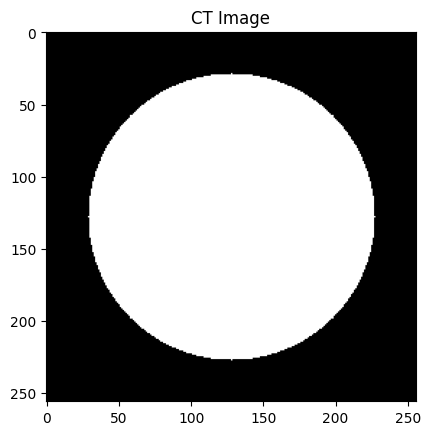

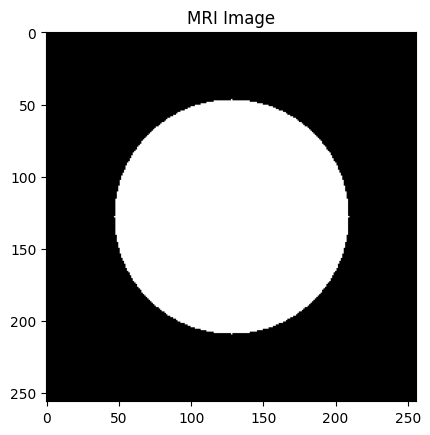

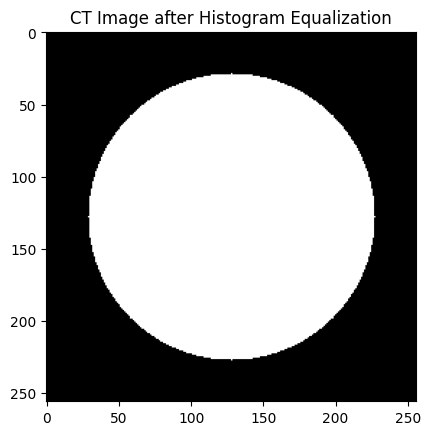

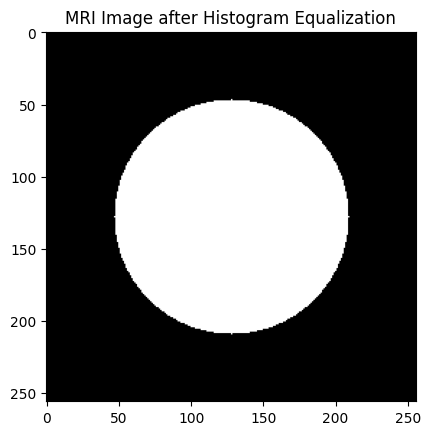

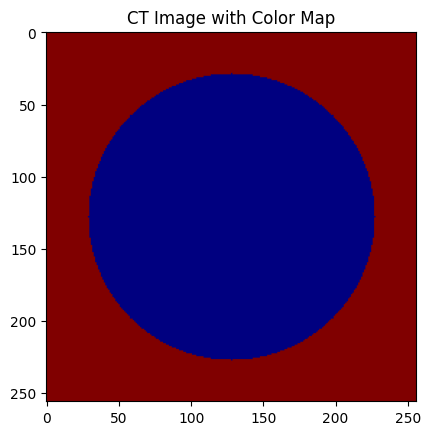

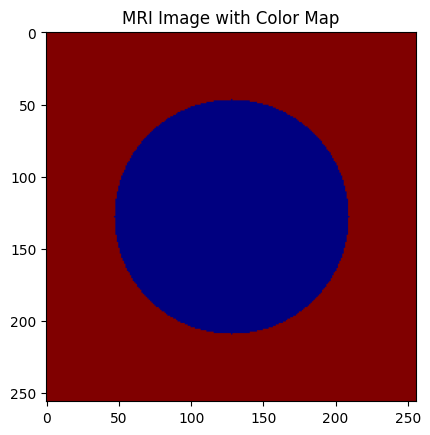

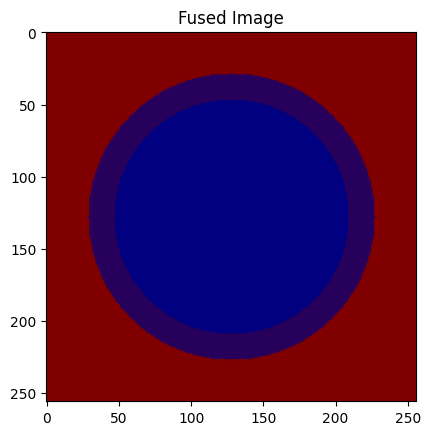

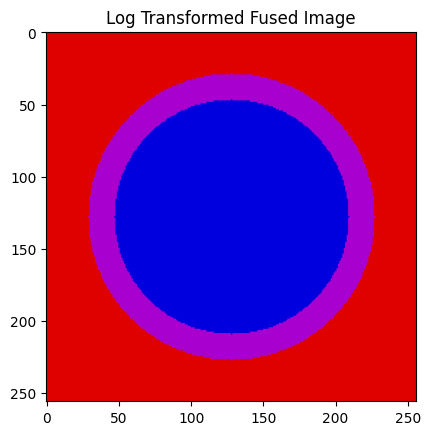

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..229.06140831794124].


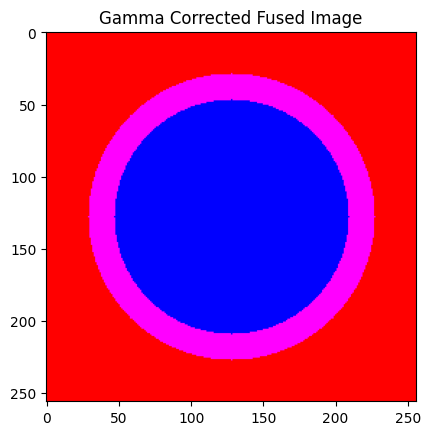

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ct = cv2.imread(r'D:\Danias Code\CV\LAB 02\task2_cardian_fusion\synthetic_slices\Patient_001\CT\slice_001.png', 0)
mri = cv2.imread(r'D:\Danias Code\CV\LAB 02\task2_cardian_fusion\synthetic_slices\Patient_001\MRI\slice_001.png', 0)
plt.figure()
plt.imshow(ct, cmap='gray')
plt.title('CT Image')
plt.show()

plt.figure()
plt.imshow(mri, cmap='gray')
plt.title('MRI Image')
plt.show()  

mri = cv2.resize(mri, (ct.shape[1], ct.shape[0]))
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

plt.figure()
plt.imshow(ct_eq, cmap='gray')  
plt.title('CT Image after Histogram Equalization')
plt.show()

plt.figure()
plt.imshow(mri_eq, cmap='gray')
plt.title('MRI Image after Histogram Equalization')
plt.show()

ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_JET)
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

plt.figure()
plt.imshow(ct_color)    
plt.title('CT Image with Color Map')
plt.show()  

plt.figure()
plt.imshow(mri_color)
plt.title('MRI Image with Color Map')
plt.show()

fused = cv2.addWeighted(ct_color, 0.7, mri_color, 0.3, 0)
plt.figure()
plt.imshow(fused)   
plt.title('Fused Image')
plt.show()

f = fused.astype(np.float32)
log_img = 255/ np.log(256) * np.log(1 + f)
log_img = np.uint8(log_img)
plt.figure()
plt.imshow(log_img)
plt.title('Log Transformed Fused Image')
plt.show()


gamma_img = 255*(log_img/255)**0.8
plt.figure()
plt.imshow(gamma_img)
plt.title('Gamma Corrected Fused Image')
plt.show()









